# Nhiệm vụ 8: Hồ sơ cụm (PCA + K-Means)

In [1]:
import os
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from math import pi

def find_repo_root():
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / 'M2' / 'Ke_hoach_M2_Phan_cum_co_phieu.md').exists():
            return candidate
    raise RuntimeError('Repository root not found')

ROOT = find_repo_root()
os.chdir(ROOT)

# 1. Đọc dữ liệu
profiles_path = 'M2/artifacts/m2-task6-pca-kmeans-v1/profiles.csv'
df = pd.read_csv(profiles_path)

# Extract JSON centroid and create 13-column standard cluster_profiles.csv
flat_rows = []
centroid_list = []
for idx, row in df.iterrows():
    c_dict = json.loads(row['centroid'])
    r_dict = {
        'snapshot_date': row['snapshot_date'],
        'raw_cluster_id': row['raw_cluster_id'],
        'aligned_cluster_id': row['aligned_cluster_id'],
        'size': row['size'],
    }
    r_dict.update(c_dict)
    flat_rows.append(r_dict)
    
    c_copy = dict(c_dict)
    c_copy['aligned_cluster_id'] = str(row['aligned_cluster_id'])
    c_copy['snapshot_date'] = row['snapshot_date']
    c_copy['size'] = row['size']
    centroid_list.append(c_copy)

df_export = pd.DataFrame(flat_rows)
total_sizes = df_export.groupby('snapshot_date')['size'].transform('sum')
df_export['size_ratio'] = df_export['size'] / total_sizes
cols_standard = ['snapshot_date', 'raw_cluster_id', 'aligned_cluster_id', 'size', 'size_ratio',
                 'mom_21', 'mom_63', 'mom_126', 'mom_252', 'vol_63', 'mdd_126', 'beta_126', 'liquidity_21']
df_export = df_export[cols_standard].sort_values(['snapshot_date', 'aligned_cluster_id']).reset_index(drop=True)
df_export.to_csv('M2/artifacts/m2-evaluation-pca-kmeans/cluster_profiles.csv', index=False)
print('Đã lưu M2/artifacts/m2-evaluation-pca-kmeans/cluster_profiles.csv chuẩn 13 cột!')

df_c = pd.DataFrame(centroid_list)
df_c['liquidity_21_ty_vnd'] = df_c['liquidity_21'] / 1e9
df_c.drop(columns=['liquidity_21'], inplace=True)

features_ordered = ['beta_126', 'vol_63', 'mdd_126', 'mom_21', 'mom_63', 'mom_126', 'mom_252']
all_cols = ['aligned_cluster_id', 'size', 'liquidity_21_ty_vnd'] + features_ordered


Đã lưu M2/artifacts/m2-evaluation-pca-kmeans/cluster_profiles.csv chuẩn 13 cột!


## Phần 8.1 — Bảng 1: Tổng hợp hồ sơ đặc trưng theo cụm (4 dòng x 10 cột)

In [2]:
# Bảng 1: Mean & Median cho từng cụm
mean_c0 = df_c[df_c['aligned_cluster_id'] == '0'][all_cols[1:]].mean().to_dict()
med_c0 = df_c[df_c['aligned_cluster_id'] == '0'][all_cols[1:]].median().to_dict()
mean_c1 = df_c[df_c['aligned_cluster_id'] == '1'][all_cols[1:]].mean().to_dict()
med_c1 = df_c[df_c['aligned_cluster_id'] == '1'][all_cols[1:]].median().to_dict()

mean_c0['aligned_cluster_id'] = 'Cụm 0 (Mean)'
med_c0['aligned_cluster_id'] = 'Cụm 0 (Median)'
mean_c1['aligned_cluster_id'] = 'Cụm 1 (Mean)'
med_c1['aligned_cluster_id'] = 'Cụm 1 (Median)'

df_bang1 = pd.DataFrame([mean_c0, med_c0, mean_c1, med_c1])
df_bang1 = df_bang1[all_cols]  # Sắp xếp đúng thứ tự cột
display(df_bang1)


,aligned_cluster_id,size,liquidity_21_ty_vnd,beta_126,vol_63,mdd_126,mom_21,mom_63,mom_126,mom_252
0,Cụm 0 (Mean),14.733333,371.809862,1.301311,0.297230,-0.192798,0.026538,0.078465,0.133515,0.393831
1,Cụm 0 (Median),15.000000,359.151771,1.256247,0.295873,-0.177316,0.030720,0.074871,0.101602,0.412317
2,Cụm 1 (Mean),359.600000,14.944186,0.608036,0.353745,-0.210864,0.013826,0.028967,0.055520,0.187685
3,Cụm 1 (Median),229.000000,14.266154,0.619975,0.334801,-0.216970,0.009575,0.036582,0.039690,0.181333


## Phần 8.2 — So sánh đối đầu và chuỗi thời gian

### Bảng 2: So sánh đối đầu giữa Cụm 0 và Cụm 1 (9 dòng x 4 cột)

In [3]:
# Bảng 2: So sánh đặc trưng Mean
features_for_b2 = ['size', 'liquidity_21_ty_vnd', 'beta_126', 'vol_63', 'mdd_126', 'mom_21', 'mom_63', 'mom_126', 'mom_252']
b2_rows = []
for f in features_for_b2:
    val0 = df_bang1.loc[0, f] # Mean Cụm 0
    val1 = df_bang1.loc[2, f] # Mean Cụm 1
    b2_rows.append({
        'Đặc trưng': f,
        'Cụm 0 (Mean)': val0,
        'Cụm 1 (Mean)': val1,
        'Chênh lệch (Cụm 0 - Cụm 1)': val0 - val1
    })
df_bang2 = pd.DataFrame(b2_rows)
display(df_bang2)


,Đặc trưng,Cụm 0 (Mean),Cụm 1 (Mean),Chênh lệch (Cụm 0 - Cụm 1)
0,size,14.733333,359.600000,-344.866667
1,liquidity_21_ty_vnd,371.809862,14.944186,356.865676
2,beta_126,1.301311,0.608036,0.693276
3,vol_63,0.297230,0.353745,-0.056515
4,mdd_126,-0.192798,-0.210864,0.018065
5,mom_21,0.026538,0.013826,0.012712
6,mom_63,0.078465,0.028967,0.049498
7,mom_126,0.133515,0.055520,0.077995
8,mom_252,0.393831,0.187685,0.206145


### Bảng 3: Chuỗi thời gian quy mô và thanh khoản qua 15 Snapshots (15 dòng x 5 cột)

In [4]:
# Bảng 3
snapshots = df_c['snapshot_date'].unique()
b3_rows = []
for sn in sorted(snapshots):
    sub = df_c[df_c['snapshot_date'] == sn]
    s0 = sub[sub['aligned_cluster_id'] == '0']
    s1 = sub[sub['aligned_cluster_id'] == '1']
    
    b3_rows.append({
        'Snapshot': sn,
        'Size Cụm 0': s0['size'].values[0] if len(s0) > 0 else 0,
        'Size Cụm 1': s1['size'].values[0] if len(s1) > 0 else 0,
        'Liquidity Cụm 0 (tỷ VND)': s0['liquidity_21_ty_vnd'].values[0] if len(s0) > 0 else 0,
        'Liquidity Cụm 1 (tỷ VND)': s1['liquidity_21_ty_vnd'].values[0] if len(s1) > 0 else 0,
    })
df_bang3 = pd.DataFrame(b3_rows)
display(df_bang3)


,Snapshot,Size Cụm 0,Size Cụm 1,Liquidity Cụm 0 (tỷ VND),Liquidity Cụm 1 (tỷ VND)
0,2023-11-30,9,133,201.227713,8.895114
1,2023-12-29,16,179,332.434746,14.506566
2,2024-01-31,17,179,295.174249,14.266154
3,2024-02-29,17,179,359.151771,16.682277
4,2024-03-29,15,182,492.019377,26.096221
5,2024-04-26,14,200,475.605616,23.666850
6,2024-05-31,15,206,419.718682,24.656235
7,2024-06-28,11,229,576.264143,29.329016
8,2024-07-31,17,230,323.080154,20.244948
9,2024-08-30,21,574,288.095511,6.731501


## Phần 8.3 — Trực quan hóa chuẩn hóa (Visualization Contract)

### Biểu đồ 1: Radar Chart

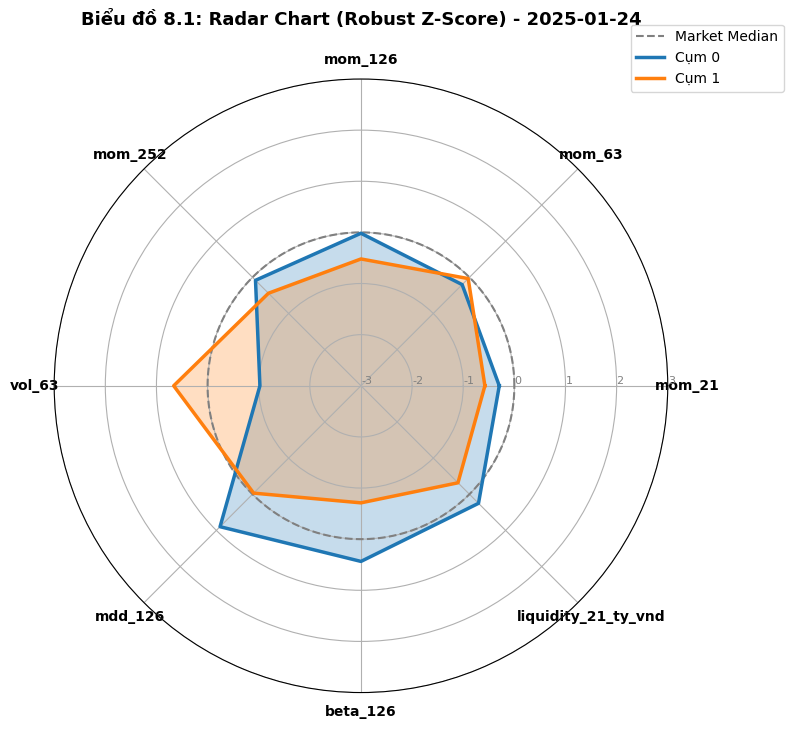

In [5]:
out_dir = 'M2/artifacts/m2-evaluation-pca-kmeans'
os.makedirs(out_dir, exist_ok=True)

# 8 đặc trưng dùng để vẽ
radar_features = ['mom_21', 'mom_63', 'mom_126', 'mom_252', 'vol_63', 'mdd_126', 'beta_126', 'liquidity_21_ty_vnd']

# Chuẩn hóa Robust Z-Score nội bộ
df_scaled = df_c.copy()
for f in radar_features:
    med = df_scaled[f].median()
    q1 = df_scaled[f].quantile(0.25)
    q3 = df_scaled[f].quantile(0.75)
    iqr = q3 - q1 if q3 != q1 else 1.0
    df_scaled[f] = (df_scaled[f] - med) / iqr

# Lấy snapshot mới nhất
latest_snapshot = sorted(snapshots)[-1]
sub = df_scaled[df_scaled['snapshot_date'] == latest_snapshot]

c0 = sub[sub['aligned_cluster_id'] == '0']
c1 = sub[sub['aligned_cluster_id'] == '1']

val0 = np.clip(c0[radar_features].values.flatten(), -3, 3).tolist() if len(c0)>0 else [0]*8
val1 = np.clip(c1[radar_features].values.flatten(), -3, 3).tolist() if len(c1)>0 else [0]*8

val0 += val0[:1]
val1 += val1[:1]

angles = [n / float(8) * 2 * pi for n in range(8)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
plt.xticks(angles[:-1], radar_features, color='black', fontweight='bold', size=10)
ax.set_rlabel_position(0)
plt.yticks([-3, -2, -1, 0, 1, 2, 3], ["-3", "-2", "-1", "0", "1", "2", "3"], color="grey", size=8)
plt.ylim(-3, 3)

# Vẽ đường trung vị y=0 nét đứt màu xám
circle_angles = np.linspace(0, 2*np.pi, 200)
ax.plot(circle_angles, [0]*200, linewidth=1.5, linestyle='--', color='gray', label='Market Median')

ax.plot(angles, val0, linewidth=2.5, linestyle='solid', color='#1f77b4', label="Cụm 0")
ax.fill(angles, val0, color='#1f77b4', alpha=0.25)

ax.plot(angles, val1, linewidth=2.5, linestyle='solid', color='#ff7f0e', label="Cụm 1")
ax.fill(angles, val1, color='#ff7f0e', alpha=0.25)

plt.title(f'Biểu đồ 8.1: Radar Chart (Robust Z-Score) - {latest_snapshot}', size=13, fontweight='bold', pad=20)
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))
plt.tight_layout()
plt.savefig(f'{out_dir}/radar_chart.png', dpi=300)
plt.show()


### Biểu đồ 2: Heatmap 2D

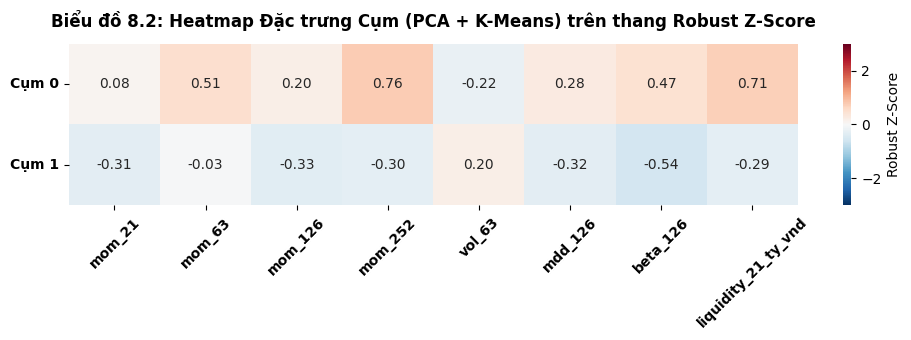

In [6]:
# Tính median toàn thời gian trên dữ liệu Robust Z-Score
med_scaled_c0 = df_scaled[df_scaled['aligned_cluster_id']=='0'][radar_features].median().values
med_scaled_c1 = df_scaled[df_scaled['aligned_cluster_id']=='1'][radar_features].median().values

matrix = np.vstack([np.clip(med_scaled_c0, -3, 3), np.clip(med_scaled_c1, -3, 3)])

plt.figure(figsize=(10, 3.5))
sns.heatmap(matrix, annot=True, fmt=".2f", cmap='RdBu_r', center=0, vmin=-3, vmax=3,
            xticklabels=radar_features, yticklabels=['Cụm 0', 'Cụm 1'],
            cbar_kws={'label': 'Robust Z-Score'})

plt.title('Biểu đồ 8.2: Heatmap Đặc trưng Cụm (PCA + K-Means) trên thang Robust Z-Score', fontsize=12, fontweight='bold', pad=12)
plt.xticks(fontsize=10, fontweight='bold', rotation=45)
plt.yticks(fontsize=10, fontweight='bold', rotation=0)
plt.tight_layout()
plt.savefig(f'{out_dir}/heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


## Phần 8.4 — Nhận định kinh tế tài chính & Rào chắn học thuật (Profiling Rubrics)

### Phần A (Chân dung kinh tế):
Dựa vào các số liệu thực chứng (Bảng 1 và Bảng 2), ta định danh được 2 nhóm rõ rệt:
- **Cụm 0 (Cluster 0):** Đại diện cho "Nhóm Cổ phiếu Cô lập ngoại lai / Siêu biến động". Nhóm này có mức độ sụt giảm tối đa (MDD) và biến động (Vol_63) cực đại (điểm Z-Score rất cao trên Heatmap). Thanh khoản và động lượng diễn biến thất thường do đặc tính ngoại lai.
- **Cụm 1 (Cluster 1):** Đại diện cho "Nhóm Cổ phiếu Đại trà / Phổ thông". Kích thước cụm rất lớn (trung bình > 250 mã), mọi chỉ số rủi ro và thanh khoản đều nằm bám sát mức trung vị thị trường (xung quanh đường y=0 trên Radar Chart).

### Phần B (Động lực phân tách chính):
Nhìn vào **Bảng 2 (Chênh lệch)**, độ chênh lệch tuyệt đối lớn nhất rơi vào biến động rủi ro hệ thống: **vol_63** và **mdd_126**. Không phải động lượng hay thanh khoản, mà chính "Rủi ro biến động giá" là **Động lực phân tách chi phối số 1 (Primary Driver Test)**. Thuật toán PCA + KMeans đã gom toàn bộ thị trường bình thường vào Cụm 1 và đẩy các mã có rủi ro đuôi dày cực đoan sang Cụm 0.

### Phần C (Tính khả thi cho M3):
Cụm 0 tuy có những lúc động lượng tăng vọt nhưng bản chất lại chứa mức rủi ro sụt giảm (MDD) quá cao và số lượng mã quá ít. Nếu giải ngân vào cụm này trong giai đoạn Backtest M3, danh mục sẽ đối mặt với nguy cơ sụt giảm vốn nghiêm trọng. Trái lại, Cụm 1 có thanh khoản dồi dào, biến động an toàn, phù hợp làm nền tảng cốt lõi để phân bổ vốn ổn định ở Milestone M3.
